In [2]:
import matplotlib.pyplot as plt
import numpy as np
import ffs_defs as ffs
import scipy
import importlib
importlib.reload(ffs)

<module 'ffs_defs' from '/home/jovyan/N3AS/ffs_defs.py'>

In [3]:
Q2_array = np.linspace(0,3,500)

In [4]:
# Compute axial from conformal variable parameterization
tc = 0.1753 # 9 * m_pi ^2, value lifted from paper
gA = -1.2723
a_list_base = [2.30, -0.6, -3.8, 2.3] 

a_list = ffs.construct_a_list(a_list_base, gA, tc)
a_std_dv_list = [.13, 1.0, 2.5, 2.7]
correlation_matrix = [[1, 0.350, -0.678, 0.611],
                      [0.350, 1, -0.898, 0.367],
                      [-0.678, -0.898, 1, -0.685],
                      [0.611, 0.367, -0.685, 1]]

data_points = ffs.generate_samples(a_list_base, a_std_dv_list, correlation_matrix, 10000) # 
a_lists = np.array([ffs.construct_a_list(a_list_sample, gA, tc) for a_list_sample in data_points])
#print(a_lists)
axial_ff_conf_array = np.array([-ffs.axial_conf(Q2, tc, a_list) for Q2 in Q2_array]) #the difference in plots comes from passing in the full a list from above

axial_ff_conf_error_array = np.array([ffs.axial_conf_err(Q2, tc, a_lists) for Q2 in Q2_array])

FNAL_a_list = ffs.construct_a_list([2.02, -1.2, -0.7, 0.1], gA, tc)
axial_ff_conf_array_FNAL = np.array([-ffs.axial_conf(Q2, tc, FNAL_a_list) for Q2 in Q2_array])

BNL_a_list = ffs.construct_a_list([2.24, 0.6, -5.4, 2.2], gA, tc)
axial_ff_conf_array_BNL = np.array([-ffs.axial_conf(Q2, tc, BNL_a_list) for Q2 in Q2_array])

ANL_a_list = ffs.construct_a_list([2.25, 0.2, -4.9, 2.7], gA, tc)
axial_ff_conf_array_ANL = np.array([-ffs.axial_conf(Q2, tc, ANL_a_list) for Q2 in Q2_array])

In [5]:
#Compute axial from dipole parameterization
mA = 1.014 
mA_std_dv = 0.014
axial_ff_dip_array = np.array([-ffs.axial_dipole(Q2, gA, mA) for Q2 in Q2_array])
axial_ff_dip_error_array = np.array([ffs.axial_dipole_err(Q2, gA, mA, mA_std_dv) for Q2 in Q2_array])
g2_conf_array = ffs.g2(Q2_array, axial_ff_conf_array, 0.938, .13957)
g2_dip_array = ffs.g2(Q2_array, axial_ff_dip_array, 0.938, .13957)

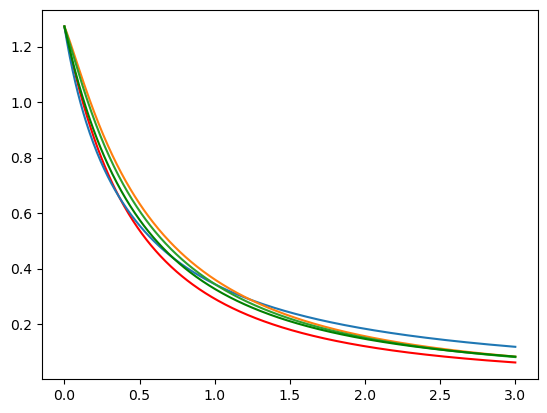

In [6]:
plt.plot(Q2_array, axial_ff_conf_array, label='conformal variable',color='red')
plt.plot(Q2_array, axial_ff_conf_array_FNAL, label='conformal variable')
plt.plot(Q2_array, axial_ff_conf_array_BNL, label='conformal variable')
plt.plot(Q2_array, axial_ff_conf_array_ANL, label='conformal variable')
plt.plot(Q2_array, axial_ff_dip_array, label='dipole',color='green')
plt.show()

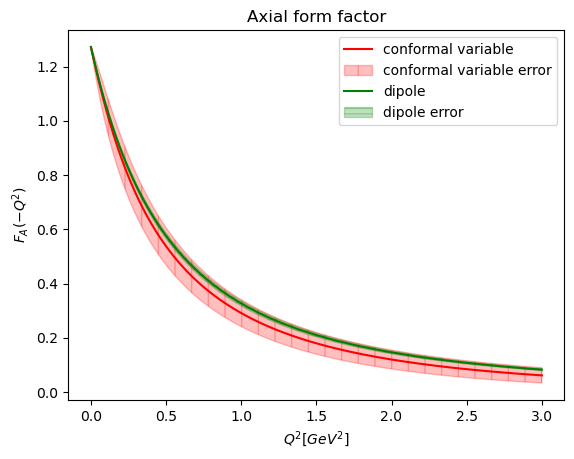

In [7]:
# Plot axial form factor
# -- conformal variable plot --
plt.plot(Q2_array, axial_ff_conf_array, label='conformal variable',color='red')
plt.fill_between(Q2_array, 
                 axial_ff_conf_array - axial_ff_conf_error_array, 
                 axial_ff_conf_array + axial_ff_conf_error_array,
                 label='conformal variable error', 
                 color='red', 
                 hatch='|',  # Vertical hatching
                 alpha=0.25)  # Semi-transparent fill

# -- dipole plot --
plt.plot(Q2_array, axial_ff_dip_array, label='dipole',color='green')
plt.fill_between(Q2_array, 
                 axial_ff_dip_array - axial_ff_dip_error_array, 
                 axial_ff_dip_array + axial_ff_dip_error_array,
                 label='dipole error', 
                 color='green', 
                 hatch='---',  # Vertical hatching
                 alpha=0.25)  # Semi-transparent fill
plt.title('Axial form factor')
plt.ylabel(r'$F_A(-Q^2)$')
plt.xlabel('$Q^2[GeV^2]$')
plt.legend()

In [8]:
kp = 1.792
kn = -1.913
mu_p = 2.793
mu_n = -1.913

# initialize coeffs from BBBA05
GEp_coeffs = [np.array([1.0, -0.0578]), np.array([11.1, 13.6, 33.0])]#checked
GMp_coeffs = [np.array([1.0, 0.150]), np.array([11.1, 19.6, 7.54])]#checked
GEn_coeffs = [np.array([0.0, 1.25, 1.30]),np.array([-9.86, 305.0, -758.0, 802.0])]#checked
GMn_coeffs = [np.array([1.0, 1.81]), np.array([14.1, 20.7, 68.7])]#checked

GEp_errs = [np.array([0.0,  0.166]), np.array([0.217, 1.39, 8.95])]#checked
GMp_errs = [np.array([0.0, 0.0312]), np.array([0.103, 0.281, 0.967])]#checked
GEn_errs = [np.array([0.0, 0.368, 1.99]), np.array([6.46,  28.6,   77.5,  156.0])]#checked
GMn_errs = [np.array([0.0, 0.402]), np.array([0.597, 2.55, 14.1])]#checked

In [9]:
importlib.reload(ffs)
N = 1000
# initialize y value arrays for all G functions
# Rescale from normalized Padé to actual form factors
# GEp and GEn don't need rescaling (normalized by 1)
# GMp and GMn need to be multiplied by their magnetic moments
Gep_array = np.array([ffs.pade_G(Q2, 0.938, GEp_coeffs[0], GEp_coeffs[1]) for Q2 in Q2_array])
Gmp_array = mu_p * np.array([ffs.pade_G(Q2, 0.938, GMp_coeffs[0], GMp_coeffs[1]) for Q2 in Q2_array])
Gen_array = np.array([ffs.pade_G(Q2, 0.939, GEn_coeffs[0], GEn_coeffs[1]) for Q2 in Q2_array])
Gmn_array = mu_n * np.array([ffs.pade_G(Q2, 0.939, GMn_coeffs[0], GMn_coeffs[1]) for Q2 in Q2_array])

#create samples of a_k, b_k for MC sampling
GEp_coef_samples = ffs.generate_G_coef_samples(GEp_coeffs[0], GEp_coeffs[1], GEp_errs[0], GEp_errs[1], N)
GMp_coef_samples = ffs.generate_G_coef_samples(GMp_coeffs[0], GMp_coeffs[1], GMp_errs[0], GMp_errs[1], N) 
GEn_coef_samples = ffs.generate_G_coef_samples(GEn_coeffs[0], GEn_coeffs[1], np.array(GEn_errs[0])/np.sqrt(N), np.array(GEn_errs[1])/np.sqrt(N), N) # linearized sampling (scaled by 1/sqrt(N))
GMn_coef_samples = ffs.generate_G_coef_samples(GMn_coeffs[0], GMn_coeffs[1], GMn_errs[0], GMn_errs[1], N)

#Get samples of G for later error propagation
Gep_samples = np.array([ffs.pade_G_uncertainty_samples(Q2, 0.938, GEp_coef_samples[0], GEp_coef_samples[1]) for Q2 in Q2_array])
Gmp_samples = mu_p * np.array([ffs.pade_G_uncertainty_samples(Q2, 0.938, GMp_coef_samples[0], GMp_coef_samples[1]) for Q2 in Q2_array])
Gen_samples = np.sqrt(N) * np.array([ffs.pade_G_uncertainty_samples(Q2, 0.939, GEn_coef_samples[0], GEn_coef_samples[1]) for Q2 in Q2_array]) # linearized sampling
Gmn_samples = mu_n * np.array([ffs.pade_G_uncertainty_samples(Q2, 0.939, GMn_coef_samples[0], GMn_coef_samples[1]) for Q2 in Q2_array])

#initialize all G uncertainty arrays
Gep_array_unc = np.array([np.std(ffs.pade_G_uncertainty_samples(Q2, 0.938, GEp_coef_samples[0], GEp_coef_samples[1])) for Q2 in Q2_array])
Gmp_array_unc = mu_p * np.array([np.std(ffs.pade_G_uncertainty_samples(Q2, 0.938, GMp_coef_samples[0], GMp_coef_samples[1])) for Q2 in Q2_array])
Gen_array_unc = np.sqrt(N) * np.array([np.std(ffs.pade_G_uncertainty_samples(Q2, 0.939, GEn_coef_samples[0], GEn_coef_samples[1])) for Q2 in Q2_array]) # linearized sampling (scaled by sqrt(N))
Gmn_array_unc = mu_n * np.array([np.std(ffs.pade_G_uncertainty_samples(Q2, 0.939, GMn_coef_samples[0], GMn_coef_samples[1])) for Q2 in Q2_array])

Text(0.5, 0, '$Q^2[GeV^2]$')

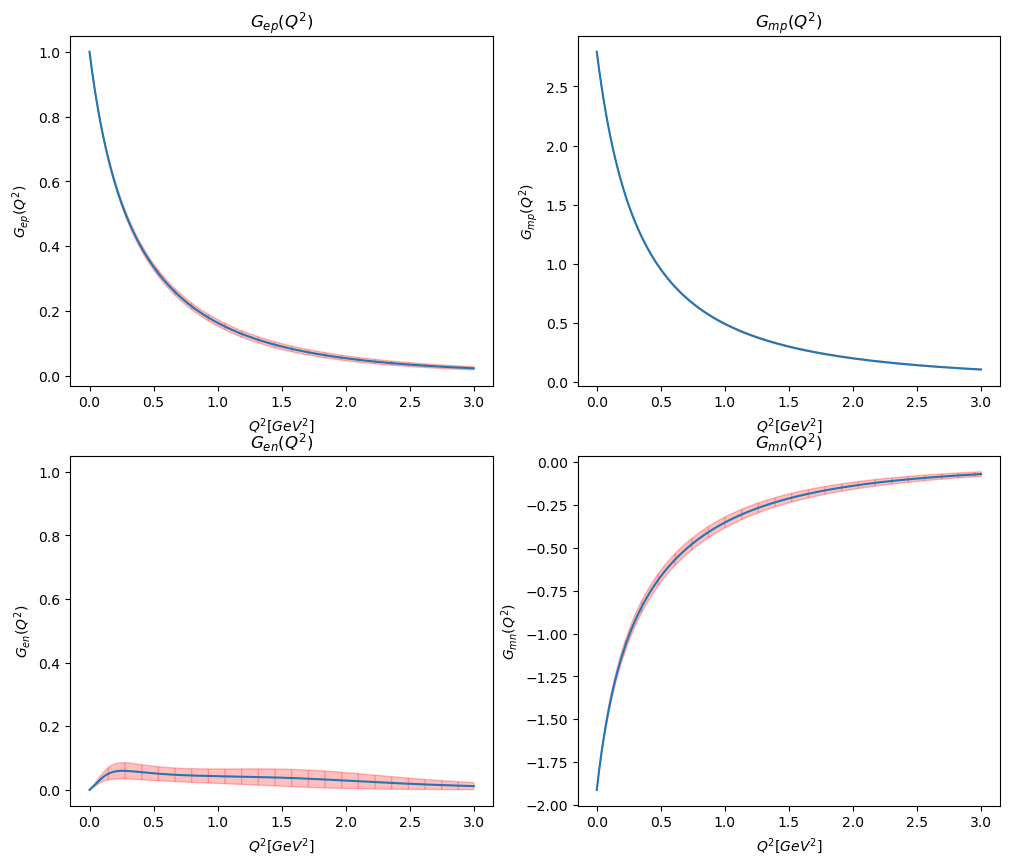

In [10]:
#plot electric and magnetic Gs
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs[0,0].plot(Q2_array,Gep_array)
axs[0,0].fill_between(Q2_array, 
                 Gep_array - Gep_array_unc, 
                 Gep_array + Gep_array_unc,
                 label='Gep error', 
                 color='red', 
                 hatch='|',  # Vertical hatching
                 alpha=0.25)  # Semi-transparent fill
axs[0,0].set_title('$G_{ep}(Q^2)$')
axs[0,0].set_ylabel('$G_{ep}(Q^2)$')
axs[0,0].set_xlabel('$Q^2[GeV^2]$')

axs[0,1].plot(Q2_array,Gmp_array)
axs[0,1].fill_between(Q2_array, 
                 Gmp_array - Gmp_array_unc, 
                 Gmp_array + Gmp_array_unc,
                 label='Gmp error', 
                 color='red', 
                 hatch='|',  # Vertical hatching
                 alpha=0.25)  # Semi-transparent fill
axs[0,1].set_title('$G_{mp}(Q^2)$')
axs[0,1].set_ylabel('$G_{mp}(Q^2)$')
axs[0,1].set_xlabel('$Q^2[GeV^2]$')

axs[1,0].plot(Q2_array,Gen_array, True)
axs[1,0].fill_between(Q2_array, 
                 Gen_array - Gen_array_unc, 
                 Gen_array + Gen_array_unc,
                 label='Gen error', 
                 color='red', 
                 hatch='|',  # Vertical hatching
                 alpha=0.25)  # Semi-transparent fill
axs[1,0].set_title('$G_{en}(Q^2)$')
axs[1,0].set_ylabel('$G_{en}(Q^2)$')
axs[1,0].set_xlabel('$Q^2[GeV^2]$')

axs[1,1].plot(Q2_array,Gmn_array)
axs[1,1].fill_between(Q2_array, 
                 Gmn_array - Gmn_array_unc, 
                 Gmn_array + Gmn_array_unc,
                 label='Gmn error', 
                 color='red', 
                 hatch='|',  # Vertical hatching
                 alpha=0.25)  # Semi-transparent fill
axs[1,1].set_title('$G_{mn}(Q^2)$')
axs[1,1].set_ylabel('$G_{mn}(Q^2)$')
axs[1,1].set_xlabel('$Q^2[GeV^2]$')


[ 1.     -0.0578] [11.1 13.6 33. ]
[1.   0.15] [11.1  19.6   7.54]
[0.   1.25 1.3 ] [  -9.86  305.   -758.    802.  ]
[1.   1.81] [14.1 20.7 68.7]
1.0
2.793
0.0
-1.913


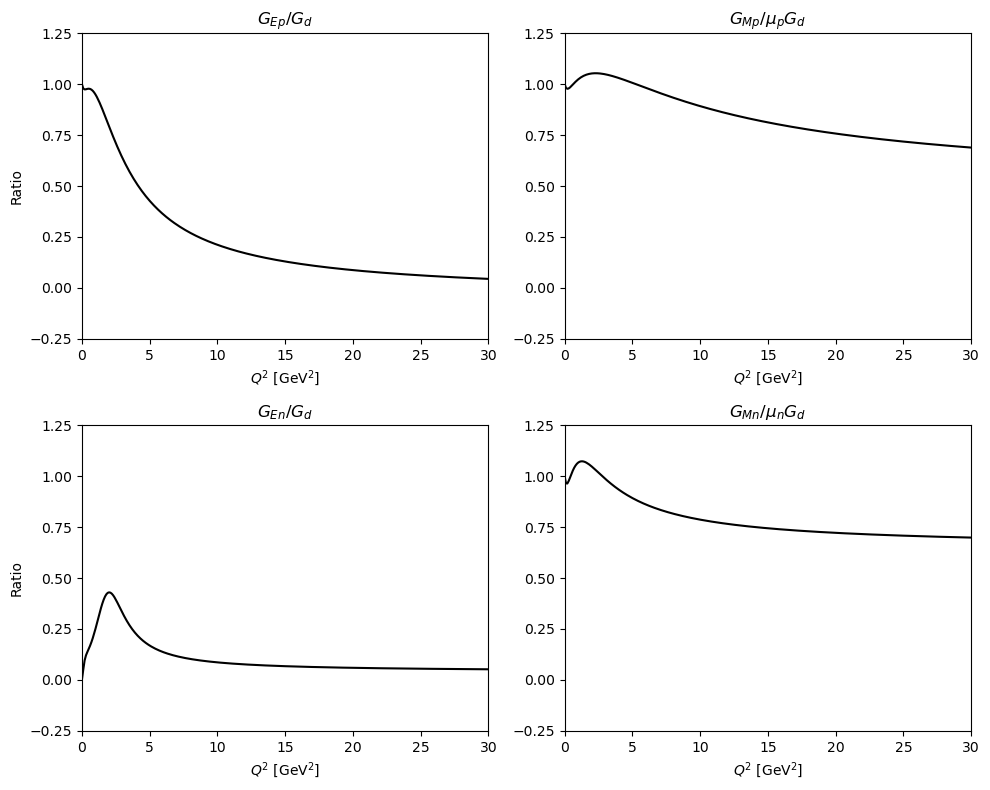

In [11]:
Q2_bbba = np.linspace(0, 30, 300)

Gd  = np.array([ffs.dipole_Gd(Q2) for Q2 in Q2_bbba])
GEp = np.array([ffs.pade_G(Q2, 0.938, GEp_coeffs[0], GEp_coeffs[1]) for Q2 in Q2_bbba])
GMp = mu_p * np.array([ffs.pade_G(Q2, 0.938, GMp_coeffs[0], GMp_coeffs[1]) for Q2 in Q2_bbba])
GEn = np.array([ffs.pade_G(Q2, 0.939, GEn_coeffs[0], GEn_coeffs[1]) for Q2 in Q2_bbba])
GMn = mu_n * np.array([ffs.pade_G(Q2, 0.939, GMn_coeffs[0], GMn_coeffs[1]) for Q2 in Q2_bbba])

print(GEp_coeffs[0], GEp_coeffs[1])
print(GMp_coeffs[0], GMp_coeffs[1])
print(GEn_coeffs[0], GEn_coeffs[1])
print(GMn_coeffs[0], GMn_coeffs[1])

print(GEp[0])
print(GMp[0])
print(GEn[0])
print(GMn[0])

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, ff, title in zip(axes.flat,
                         [GEp, GMp/mu_p, GEn,  GMn/mu_n],
                         [r'$G_{Ep}/G_d$', r'$G_{Mp}/\mu_p G_d$',
                          r'$G_{En}/G_d$', r'$G_{Mn}/\mu_n G_d$']):
    ax.plot(Q2_bbba, ff / Gd, 'k-')
    ax.set_title(title)
    ax.set_xlim(0, 30)
    ax.set_ylim(0, 1.25)
    ax.set_xlabel(r'$Q^2\ [\mathrm{GeV}^2]$')
    ax.set_yticks([-0.25, 0, 0.25, 0.5, 0.75, 1, 1.25])
axes[0, 0].set_ylabel('Ratio')
axes[1, 0].set_ylabel('Ratio')
plt.tight_layout()
plt.show()

Text(0.5, 0, '$Q^2[GeV^2]$')

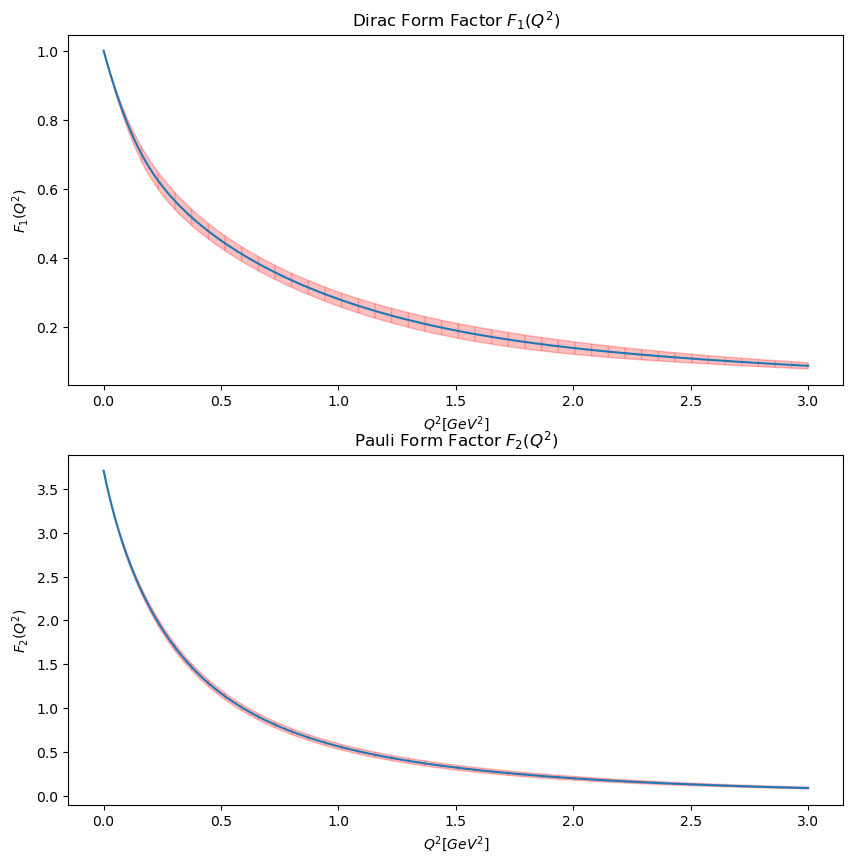

In [12]:
importlib.reload(ffs)

#initialize sachs vector current form factors
G_ve = Gep_array - Gen_array
G_vm = Gmp_array - Gmn_array

# plt.plot(Q2_array, G_ve)
# plt.plot(Q2_array, G_vm)

#calculate F1, F2 arrays
f1_array= ffs.calculate_F1(Q2_array, 0.9389 ,G_ve , G_vm)
f2_array= ffs.calculate_F2(Q2_array, 0.9389 ,G_ve , G_vm)

#gather uncertainties for Dirac and Pauli vector current form factors
#each G_samples[i] is 1000 G samples
f1_array_unc = np.array([ffs.F1_uncertainty(Q2, 0.9389, Gep_samples[i], Gmp_samples[i], Gen_samples[i], Gmn_samples[i]) for i, Q2 in enumerate(Q2_array)])
f2_array_unc = np.array([ffs.F2_uncertainty(Q2, 0.9389, Gep_samples[i], Gmp_samples[i], Gen_samples[i], Gmn_samples[i]) for i, Q2 in enumerate(Q2_array)])

# Plot vector form factor
fig, axs = plt.subplots(2, 1, figsize=(10, 10))
axs[0].plot(Q2_array,f1_array)
axs[0].set_title('Dirac Form Factor $F_{1}(Q^2)$')
axs[0].fill_between(Q2_array, 
                 f1_array - f1_array_unc, 
                 f1_array + f1_array_unc,
                 label='f1 error', 
                 color='red', 
                 hatch='|',  # Vertical hatching
                 alpha=0.25  # Semi-transparent fill
                 )
axs[0].set_ylabel('$F_{1}(Q^2)$')
axs[0].set_xlabel('$Q^2[GeV^2]$')

axs[1].plot(Q2_array,f2_array)
axs[1].set_title('Pauli Form Factor $F_{2}(Q^2)$')
axs[1].fill_between(Q2_array, 
                 f2_array - f2_array_unc, 
                 f2_array + f2_array_unc,
                 label='f2 error', 
                 color='red', 
                 hatch='|',  # Vertical hatching
                 alpha=0.25)  # Semi-transparent fill
axs[1].set_ylabel('$F_{2}(Q^2)$')
axs[1].set_xlabel('$Q^2[GeV^2]$')


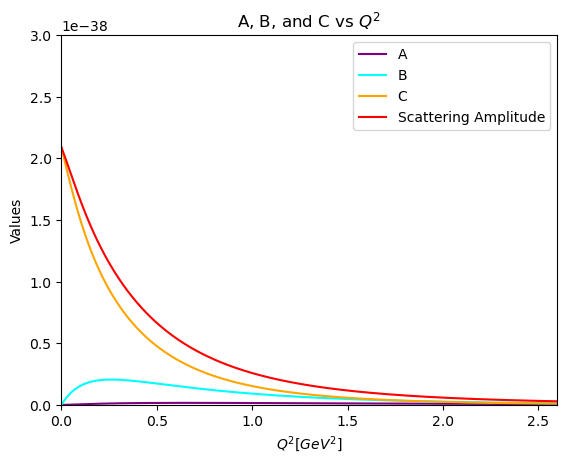

In [13]:
importlib.reload(ffs)

Ev = 2 #[GeV], given for plot 3 in meyer deuterium paper
m_N = 0.938 #neutron mass [GeV]
m_l = 0.10566 # muon mass [GeV]
s_u = 4*Ev*m_N - Q2_array - m_l**2 # s - u
G_F = 1.16637e-5 #fermi coupling constant
cosc = 0.9746 # cosine of cabibbo angle
hbc = 0.1973e-13 # conversion factor, has units [Gev * cm]
norm = (m_N*G_F*cosc)**2/(8*np.pi*(Ev**2)) * (hbc)**2

A_array = ffs.A_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_conf_array, g2_conf_array)
B_array = ffs.B_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_conf_array, g2_conf_array)
C_array = ffs.C_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_conf_array, g2_conf_array)

A_array_2 = ffs.A_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_dip_array, g2_dip_array) 
B_array_2 = ffs.B_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_dip_array, g2_dip_array) #* ((s_u)/(m_N**2))
C_array_2 = ffs.C_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_dip_array, g2_dip_array) #*((s_u)/(m_N**2))**2

scattering_amplitude_1 = (A_array + B_array*((s_u)/(m_N**2)) + C_array*((s_u)/(m_N**2))**2)
scattering_amplitude_2 = (A_array_2 + B_array_2*((s_u)/(m_N**2)) + C_array_2*((s_u)/(m_N**2))**2)


# Plot A, B, and C
plt.plot(Q2_array, A_array * norm, label='A', color='purple')
plt.plot(Q2_array, B_array*((s_u)/(m_N**2))* norm, label='B', color='cyan')
plt.plot(Q2_array,  C_array*((s_u)/(m_N**2))**2 * norm, label='C', color='orange')
plt.plot(Q2_array, scattering_amplitude_1* norm, label='Scattering Amplitude', color='red')

# plt.plot(Q2_array, A_array_2, label='A', color='purple')
# plt.plot(Q2_array, B_array_2, label='B', color='cyan')
# plt.plot(Q2_array, C_array_2, label='C', color='orange')
#plt.plot(Q2_array, scattering_amplitude_2, label='Scattering Amplitude', color='red')

# Add title and labels
plt.title('A, B, and C vs $Q^2$')
plt.ylabel('Values')
plt.xlabel('$Q^2 [GeV^2]$')
# plt.ylim(0,2e-39)
plt.xlim(0, 2.6)
plt.ylim(0, 3e-38)
# Display the legend
plt.legend()

# Show the plot
plt.show()


2.0952173131284915e-38
2.0952173131284915e-38


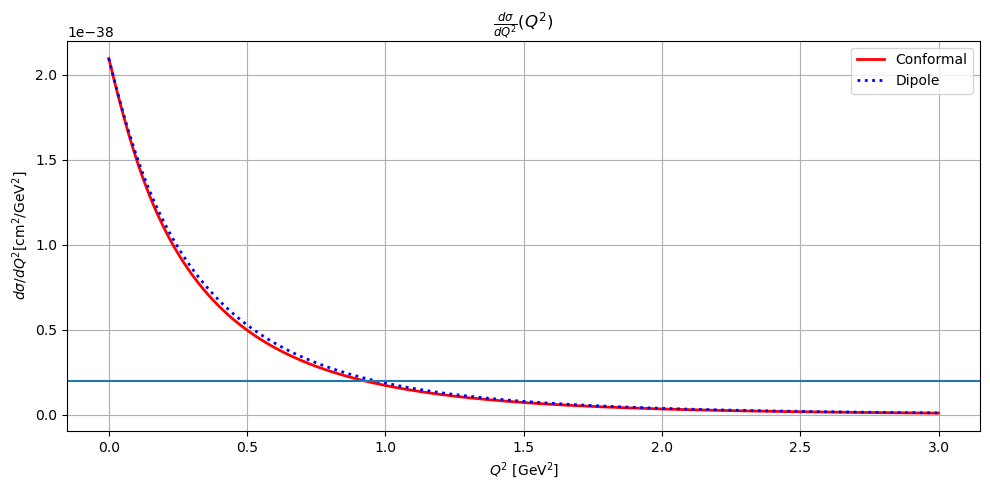

In [14]:
importlib.reload(ffs)
Ev = 10 #[GeV], given for plot 3 in meyer deuterium paper
m_N = 0.9389 #neutron mass [GeV]
m_l = 0.10566 # muon mass [GeV]
s_u = 4*Ev*m_N - Q2_array - m_l**2 # s - u
G_F = 1.16637e-5 #fermi coupling constant
cosc = 0.9746 # cosine of cabibbo angle
hbc = 0.1973e-13 # conversion factor, has units [Gev * cm]
#conformal
mA = 1.014
axial_ff_dip_array = np.array([-ffs.axial_dipole(Q2, gA, mA) for Q2 in Q2_array])
g2_conf_array = ffs.g2(Q2_array, axial_ff_conf_array, 0.9389, .13957)
g2_dip_array = ffs.g2(Q2_array, axial_ff_dip_array, 0.9389, .13957)

A_array = ffs.A_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_conf_array, g2_conf_array)
B_array = ffs.B_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_conf_array, g2_conf_array)
C_array = ffs.C_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_conf_array, g2_conf_array)

#dipole
A_array_2 = ffs.A_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_dip_array, g2_dip_array)
B_array_2 = ffs.B_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_dip_array, g2_dip_array)
C_array_2 = ffs.C_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_dip_array, g2_dip_array)

diff_cs_1 = ffs.diff_cs(Ev, Q2_array, m_l, m_N, A_array, B_array, C_array, G_F=1.16637e-5, cosc=0.9746, hbc=0.1973e-13)
diff_cs_2 = ffs.diff_cs(Ev, Q2_array, m_l, m_N, A_array_2, B_array_2, C_array_2, G_F=1.16637e-5, cosc=0.9746, hbc=0.1973e-13)


# Plot
fig, axs = plt.subplots(1, 1, figsize=(10, 5))
axs.plot(Q2_array, diff_cs_1, 'r-', label='Conformal', linewidth=2)
print(diff_cs_1 [0])
print(diff_cs_2 [0])
axs.plot(Q2_array, diff_cs_2, 'b:', label='Dipole', linewidth=2)
# axs.plot(Q2_array, A_array_norm)
# axs.plot(Q2_array, B_array_norm, label='B')
# axs.plot(Q2_array, C_array_norm)
#plt.ylim(0, 23e-39)
axs.set_title(r'$\frac{d \sigma}{dQ^2}(Q^2)$')
axs.set_ylabel(r'${d \sigma}/{dQ^2}$[cm$^2$/GeV$^2$]')
axs.set_xlabel(r'$Q^2$ [GeV$^2$]')
axs.legend()
# axs.grid(True, alpha=0.3)
plt.tight_layout()
# plt.show()
axs.axhline(2e-39)
axs.grid()

2.0952173131284915e-38
2.0952173131284915e-38


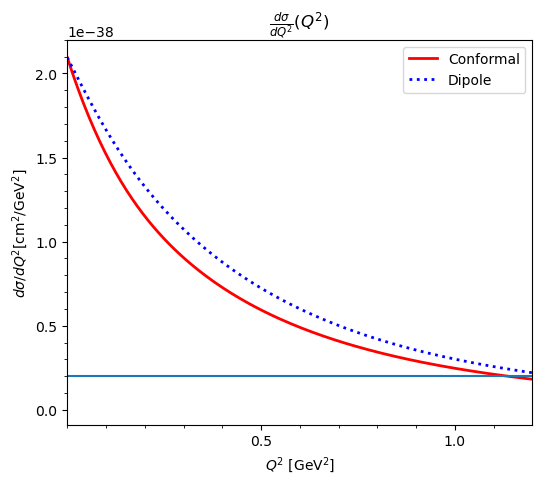

In [23]:
importlib.reload(ffs)

mA = 1.17 #using the axial mass for FNAL specifically
axial_ff_dip_array = np.array([-ffs.axial_dipole(Q2, gA, mA) for Q2 in Q2_array])
g2_conf_array = ffs.g2(Q2_array, axial_ff_conf_array, 0.9389, .13957)
g2_dip_array = ffs.g2(Q2_array, axial_ff_dip_array, 0.9389, .13957)

A_array = ffs.A_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_conf_array_FNAL, g2_conf_array)
B_array = ffs.B_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_conf_array_FNAL, g2_conf_array)
C_array = ffs.C_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_conf_array_FNAL, g2_conf_array)

#dipole
A_array_2 = ffs.A_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_dip_array, g2_dip_array)
B_array_2 = ffs.B_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_dip_array, g2_dip_array)
C_array_2 = ffs.C_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_dip_array, g2_dip_array)

diff_cs_1 = ffs.diff_cs(Ev, Q2_array, m_l, m_N, A_array, B_array, C_array, G_F=1.16637e-5, cosc=0.9746, hbc=0.1973e-13)
diff_cs_2 = ffs.diff_cs(Ev, Q2_array, m_l, m_N, A_array_2, B_array_2, C_array_2, G_F=1.16637e-5, cosc=0.9746, hbc=0.1973e-13)
print(diff_cs_1 [0])
print(diff_cs_2 [0])

# Plot
fig, axs = plt.subplots(1, 1, figsize=(6,5))
axs.plot(1.155*Q2_array, diff_cs_1, 'r-', label='Conformal', linewidth=2) # introducing a coefficient of 1.155 on Q2_array makes a near perfect fit to expected, for some reason
axs.plot(1.155*Q2_array, diff_cs_2, 'b:', label='Dipole', linewidth=2)
# axs.plot(Q2_array, A_array_norm)
# axs.plot(Q2_array, B_array_norm, label='B')
# axs.plot(Q2_array, C_array_norm)
#plt.ylim(0, 23e-39)

plt.xlim(0, 1.2)
axs.set_xticks(np.arange(0, 1.2, 0.1), minor = 'true')
axs.set_xticks([00.5, 1])
axs.set_yticks(np.arange(0, 23, 1)*1e-39, minor = 'true')
plt.axhline(2e-39)
axs.set_title(r'$\frac{d \sigma}{dQ^2}(Q^2)$')
axs.set_ylabel(r'${d \sigma}/{dQ^2}$[cm$^2$/GeV$^2$]')
axs.set_xlabel(r'$Q^2$ [GeV$^2$]')
axs.legend()

[[0.00000e+00 2.00000e-02 0.00000e+00]
 [2.00000e-02 4.00000e-02 0.00000e+00]
 [4.00000e-02 6.00000e-02 0.00000e+00]
 [6.00000e-02 8.00000e-02 0.00000e+00]
 [8.00000e-02 1.00000e-01 0.00000e+00]
 [1.00000e-01 1.20000e-01 0.00000e+00]
 [1.20000e-01 1.40000e-01 0.00000e+00]
 [1.40000e-01 1.60000e-01 0.00000e+00]
 [1.60000e-01 1.80000e-01 0.00000e+00]
 [1.80000e-01 2.00000e-01 0.00000e+00]
 [2.00000e-01 2.20000e-01 5.47983e+00]
 [2.20000e-01 2.40000e-01 1.86642e+01]
 [2.40000e-01 2.60000e-01 3.46974e+01]
 [2.60000e-01 2.80000e-01 5.34386e+01]
 [2.80000e-01 3.00000e-01 7.47470e+01]
 [3.00000e-01 3.20000e-01 9.84816e+01]
 [3.20000e-01 3.40000e-01 1.24502e+02]
 [3.40000e-01 3.60000e-01 1.52666e+02]
 [3.60000e-01 3.80000e-01 1.82834e+02]
 [3.80000e-01 4.00000e-01 2.14865e+02]]


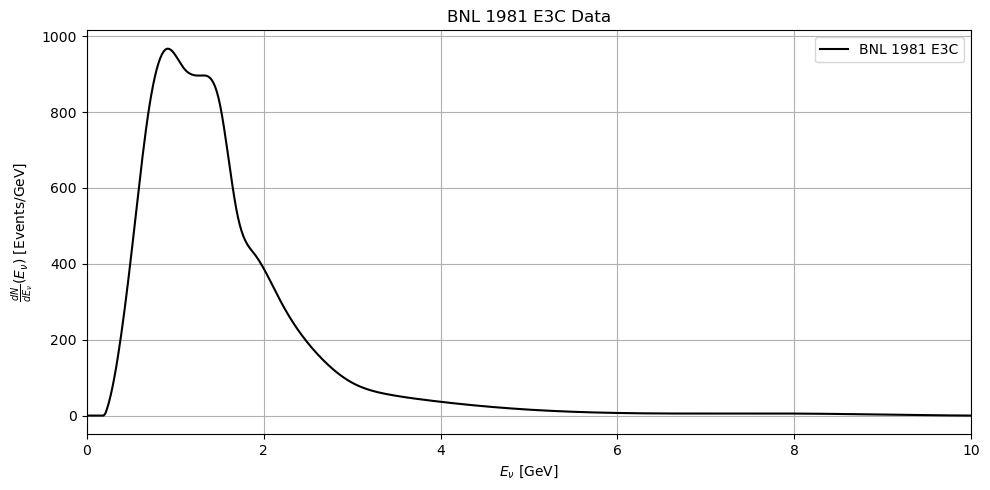

In [16]:
# Load and plot BNL 1981 E3C data
bnl_data = np.loadtxt(r"BNL_1981_E3C.dat")
#bnl_data = np.loadtxt(r"BNL_1981_E.dat")
print(bnl_data[:20,:])
bnl_E_nu = (bnl_data[:, 0] + bnl_data[:, 1]) / 2.0
bnl_N = bnl_data[:, 2]

fig, axs = plt.subplots(1, 1, figsize=(10, 5))
#axs.plot(bnl_E_nu, bnl_N, 'k-', label='BNL 1981 E3C')

axs.plot(bnl_E_nu, bnl_N, 'k-', label='BNL 1981 E3C')

plt.xlim(0, 10)
axs.set_title('BNL 1981 E3C Data')
axs.set_ylabel(r'$\frac{d N}{dE_{\nu}}(E_{\nu})$ [Events/GeV]')
axs.set_xlabel(r'$E_{\nu}$ [GeV]')
axs.legend()
plt.tight_layout()
axs.grid()

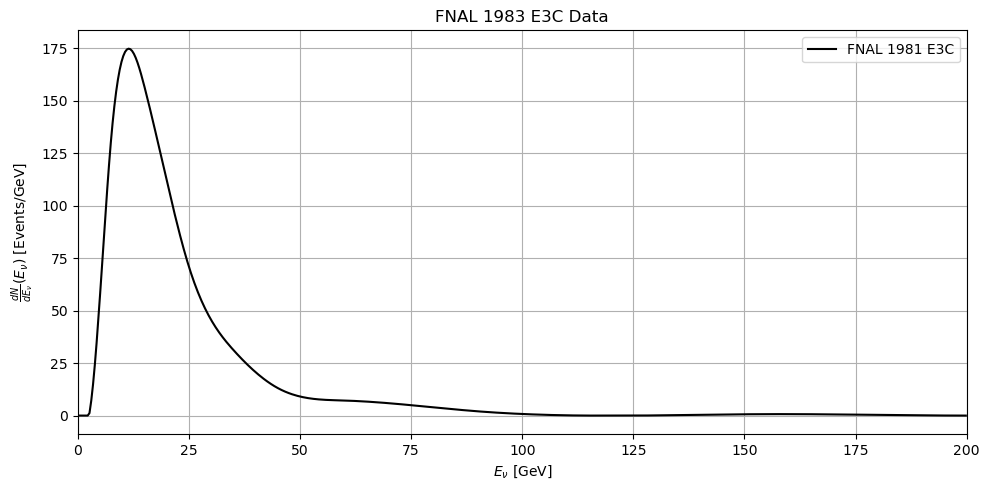

In [17]:
# Load and plot FNAL 1981 E3C data
fnal_data = np.loadtxt(r"FNAL_1983_E3C.dat")
fnal_E_nu = (fnal_data[:, 0] + fnal_data[:, 1]) / 2.0
fnal_N = fnal_data[:, 2]
fig, axs = plt.subplots(1, 1, figsize=(10, 5))

axs.plot(fnal_E_nu, fnal_N, 'k-', label='FNAL 1981 E3C')

plt.xlim(0, 200)
axs.set_title('FNAL 1983 E3C Data')
axs.set_ylabel(r'$\frac{d N}{dE_{\nu}}(E_{\nu})$ [Events/GeV]')
axs.set_xlabel(r'$E_{\nu}$ [GeV]')
axs.legend()
plt.tight_layout()
axs.grid()

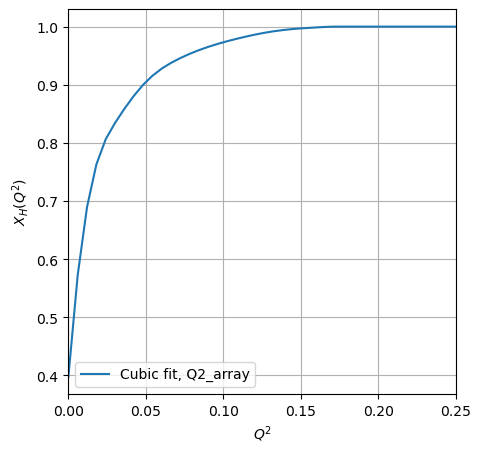

In [18]:
Q2_interp = np.array([0,0.01, 0.03, 0.05,0.07,0.09,0.11,0.13,0.15, 0.17]) # added 0.17
X_h = np.array([0.398, 0.656, 0.834, 0.905, 0.943, 0.965, 0.980, 0.991, 0.997,1]) # added a point at X_h = 1


# 2. Fit the standard spline
cs = scipy.interpolate.CubicSpline(Q2_interp, X_h)
X_h_interpolated = np.where(Q2_array <= Q2_interp.max(), cs(Q2_array), 1.0) # applies spline for within bounds, otherwise 1


fig, axs = plt.subplots(1, 1, figsize=(5, 5))
axs.plot(Q2_array, X_h_interpolated, label='Cubic fit, Q2_array')
axs.set_ylabel(r'$X_H(Q^2)$')
axs.set_xlabel(r'$Q^2$')
axs.legend()
axs.grid()
plt.xlim(0, 0.25)
plt.show()

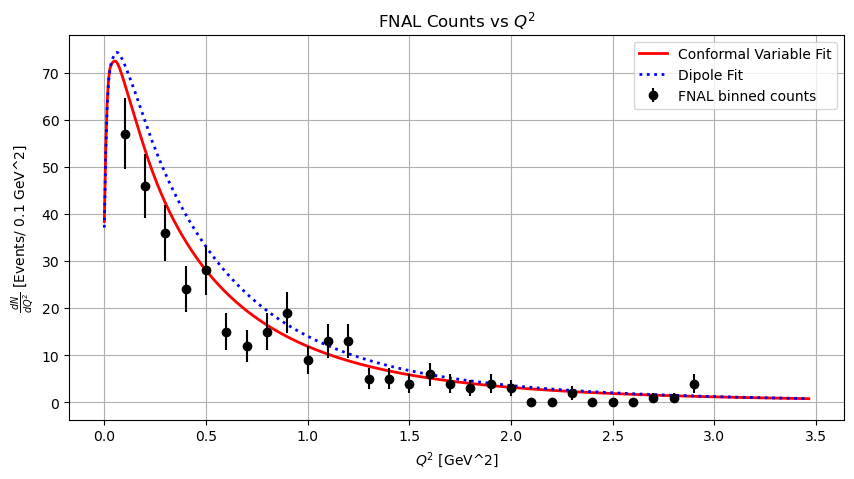

In [35]:
#USED: 
#mA = 1.17 for FNAL dipole mass
#m_N = 0.9389
# FNAL data's central value fits
# Horizontal stretch of 1.155, still don't know why that works
# Nfit of 1.21 for the d
# 
importlib.reload(ffs)
importlib.reload(ffs)
Ev = 10 #[GeV], given for plot 3 in meyer deuterium paper
m_N = 0.9389 #neutron mass [GeV]
m_l = 0.10566 # muon mass [GeV]
s_u = 4*Ev*m_N - Q2_array - m_l**2 # s - u
G_F = 1.16637e-5 #fermi coupling constant
cosc = 0.9746 # cosine of cabibbo angle
hbc = 0.1973e-13 # conversion factor, has units [Gev * cm]
#conformal
mA = 1.17
axial_ff_dip_array = np.array([-ffs.axial_dipole(Q2, gA, mA) for Q2 in Q2_array])
g2_conf_array = ffs.g2(Q2_array, axial_ff_conf_array, 0.9389, .13957)
g2_dip_array = ffs.g2(Q2_array, axial_ff_dip_array, 0.9389, .13957)

A_array = ffs.A_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_conf_array_FNAL, g2_conf_array)
B_array = ffs.B_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_conf_array_FNAL, g2_conf_array)
C_array = ffs.C_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_conf_array_FNAL, g2_conf_array)

#dipole
A_array_2 = ffs.A_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_dip_array, g2_dip_array)
B_array_2 = ffs.B_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_dip_array, g2_dip_array)
C_array_2 = ffs.C_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_dip_array, g2_dip_array)
# next up, just write my own code for the integration 
# is R(Q2, Ev) d^2\sigma/dQ2dEv? and R(Q2) is X_h? little confused. 
# what range do I integrate Q2 over for total cross section? Need Q2 upper bound from kinematics. 
# Should be a function of Ev. 
E_v_array = np.linspace(0, 10, 500)

# Ev = 10
# ffs.total_cs(10, Q2_arrayt, m_l, m_N, A_array, B_array, C_array)

fnal_1983_N= np.loadtxt(r"FNAL_1983_N.dat")

total_cs_Ev = np.array([
    ffs.total_cs(E_v, Q2_array, m_l, m_N, A_array, B_array, C_array)
    for E_v in fnal_E_nu
])
diff_cs_Ev = np.array( [
    ffs.diff_cs(E_v, Q2_array, m_l, m_N, A_array, B_array, C_array)
    for E_v in fnal_E_nu
])

total_cs_Ev_dip = np.array([
    ffs.total_cs(E_v, Q2_array, m_l, m_N, A_array_2, B_array_2, C_array_2)
    for E_v in fnal_E_nu
])

diff_cs_Ev_dip = np.array( [
    ffs.diff_cs(E_v, Q2_array, m_l, m_N, A_array_2, B_array_2, C_array_2)
    for E_v in fnal_E_nu
])

integrand = [
    1 / total_cs_Ev * diff_cs_Ev[:,jj] * X_h_interpolated[jj]
for jj in range(len(Q2_array)) ]

integrand_dip = [
    1 / total_cs_Ev * diff_cs_Ev_dip[:,jj] * X_h_interpolated[jj]
for jj in range(len(Q2_array)) ]

neutron_event_dist = np.array([
    scipy.integrate.trapezoid(integrand[ii] * fnal_N, fnal_E_nu)
    for ii in range(len(Q2_array))])

neutron_event_dist_dip = np.array([
    scipy.integrate.trapezoid(integrand_dip[ii] * fnal_N, fnal_E_nu)
    for ii in range(len(Q2_array))])

fig, axs = plt.subplots(1, 1, figsize=(10, 5))

axs.plot(1.155*Q2_array, 1.21 * neutron_event_dist*(3/354), label = 'Conformal Variable Fit', color = 'red', linewidth = 2)
axs.plot(1.155*Q2_array, 1.17 * neutron_event_dist_dip*(3/354), 'b:', label = 'Dipole Fit', linewidth = 2)
axs.errorbar((fnal_1983_N[1:,0] + fnal_1983_N[:-1,0])/2 , fnal_1983_N[1:,1], np.sqrt(fnal_1983_N[1:,1]), ls='', marker='o', color = 'black', label = 'FNAL binned counts')
axs.set_title(r'FNAL Counts vs $Q^2$')
axs.set_ylabel(r'$\frac{d N}{dQ^2}$ [Events/ 0.1 GeV^2]')
axs.set_xlabel(r'$Q^2$ [GeV^2]')
axs.legend()
axs.grid()

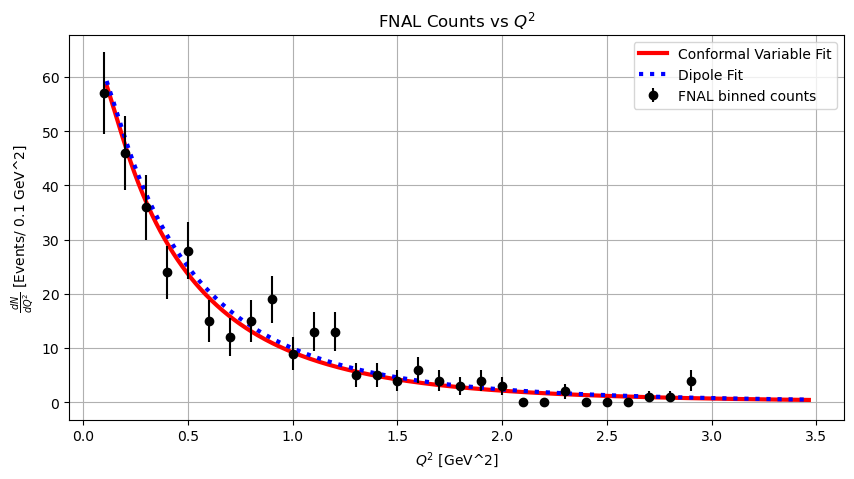

In [20]:

importlib.reload(ffs)
Ev = 10 #[GeV], given for plot 3 in meyer deuterium paper
m_N = 0.9389 #neutron mass [GeV]
m_l = 0.10566 # muon mass [GeV]
s_u = 4*Ev*m_N - Q2_array - m_l**2 # s - u
G_F = 1.16637e-5 #fermi coupling constant
cosc = 0.9746 # cosine of cabibbo angle
hbc = 0.1973e-13 # conversion factor, has units [Gev * cm]
#conformal
mA = 1.014
axial_ff_dip_array = np.array([-ffs.axial_dipole(Q2, gA, mA) for Q2 in Q2_array])
g2_conf_array = ffs.g2(Q2_array, axial_ff_conf_array, 0.9389, .13957)
g2_dip_array = ffs.g2(Q2_array, axial_ff_dip_array, 0.9389, .13957)

A_array = ffs.A_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_conf_array, g2_conf_array)
B_array = ffs.B_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_conf_array, g2_conf_array)
C_array = ffs.C_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_conf_array, g2_conf_array)

#dipole
A_array_2 = ffs.A_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_dip_array, g2_dip_array)
B_array_2 = ffs.B_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_dip_array, g2_dip_array)
C_array_2 = ffs.C_t(Q2_array, m_l, m_N, f1_array, f2_array, axial_ff_dip_array, g2_dip_array)
# next up, just write my own code for the integration 
# is R(Q2, Ev) d^2\sigma/dQ2dEv? and R(Q2) is X_h? little confused. 
# what range do I integrate Q2 over for total cross section? Need Q2 upper bound from kinematics. 
# Should be a function of Ev. 
E_v_array = np.linspace(0, 10, 500)

# Ev = 10
# ffs.total_cs(10, Q2_arrayt, m_l, m_N, A_array, B_array, C_array)

fnal_1983_N= np.loadtxt(r"FNAL_1983_N.dat")

total_cs_Ev = np.array([
    ffs.total_cs(E_v, Q2_array, m_l, m_N, A_array, B_array, C_array)
    for E_v in fnal_E_nu
])
diff_cs_Ev = np.array( [
    ffs.diff_cs(E_v, Q2_array, m_l, m_N, A_array, B_array, C_array)
    for E_v in fnal_E_nu
])

total_cs_Ev_dip = np.array([
    ffs.total_cs(E_v, Q2_array, m_l, m_N, A_array_2, B_array_2, C_array_2)
    for E_v in fnal_E_nu
])

diff_cs_Ev_dip = np.array( [
    ffs.diff_cs(E_v, Q2_array, m_l, m_N, A_array_2, B_array_2, C_array_2)
    for E_v in fnal_E_nu
])

integrand = [
    1 / total_cs_Ev * diff_cs_Ev[:,jj] * X_h_interpolated[jj]
for jj in range(len(Q2_array)) ]

integrand_dip = [
    1 / total_cs_Ev * diff_cs_Ev_dip[:,jj] * X_h_interpolated[jj]
for jj in range(len(Q2_array)) ]

neutron_event_dist = np.array([
    scipy.integrate.trapezoid(integrand[ii] * fnal_N, fnal_E_nu)
    for ii in range(len(Q2_array))])

neutron_event_dist_dip = np.array([
    scipy.integrate.trapezoid(integrand_dip[ii] * fnal_N, fnal_E_nu)
    for ii in range(len(Q2_array))])

fig, axs = plt.subplots(1, 1, figsize=(10, 5))

axs.plot(1.155*Q2_array[16:], neutron_event_dist[16:]*(3/354), label = 'Conformal Variable Fit', color = 'red', linewidth = 3)
axs.plot(1.155*Q2_array[16:], neutron_event_dist_dip[16:]*(3/354), 'b:', label = 'Dipole Fit', linewidth = 3)
axs.errorbar((fnal_1983_N[1:,0] + fnal_1983_N[:-1,0])/2 , fnal_1983_N[1:,1], np.sqrt(fnal_1983_N[1:,1]), ls='', marker='o', color = 'black', label = 'FNAL binned counts')
axs.set_title(r'FNAL Counts vs $Q^2$')
axs.set_ylabel(r'$\frac{d N}{dQ^2}$ [Events/ 0.1 GeV^2]')
axs.set_xlabel(r'$Q^2$ [GeV^2]')
axs.legend()
axs.grid()